# Flight Delay Analysis and Prediction ✈️

**Objective**: Analyze flight records from 2024 to identify key factors behind flight delays (>= 15 minutes) and train machine learning models to accurately predict them prior to departure.

*This notebook evaluates several models (Logistic Regression, Random Forest, LightGBM, and XGBoost) and selects the best performer.*


In [1]:
import pandas as pd
import numpy as np
import time
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid")
%matplotlib inline


## 1. Load Data
Loading the 2024 Domestic Flight dataset.


In [4]:
print("Loading dataset...")
start_time = time.time()
df = pd.read_csv("flight_data_2024.csv")
print(f"Loaded {len(df):,} rows and {len(df.columns)} columns in {time.time()-start_time:.1f} seconds.")
df.head()


Loading dataset...
Loaded 1,048,575 rows and 35 columns in 2.4 seconds.


,year,month,day_of_month,day_of_week,fl_date,op_unique_carrier,op_carrier_fl_num,origin,origin_city_name,origin_state_nm,...,diverted,crs_elapsed_time,actual_elapsed_time,air_time,distance,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,1,1,1,1/1/2024,9E,4814,JKH,"New York, NY",New York,...,0,136.0,122.0,84.0,509,0,0,0,0,0
1,2024,1,1,1,1/1/2024,9E,4815,MSP,"Minneapolis, MN",Minnesota,...,0,130.0,114.0,88.0,622,0,0,0,0,0
2,2024,1,1,1,1/1/2024,9E,4817,JFK,"New York, NY",New York,...,0,106.0,90.0,61.0,288,0,0,0,0,0
3,2024,1,1,1,1/1/2024,9E,4817,RIC,"Richmond, VA",Virginia,...,0,111.0,76.0,51.0,288,0,0,0,0,0
4,2024,1,1,1,1/1/2024,9E,4818,DTW,"Detroit, MI",Michigan,...,0,79.0,70.0,45.0,237,0,0,0,0,0


## 2. Data Preprocessing & Target Creation
We will exclude canceled and diverted flights, as we are strictly analyzing *delays*.
FAA dictates that any flight arriving 15 minutes or more past the CRS Arrival Time is classified as delayed.


Rows after cleaning: 1,022,824
Dataset Distribution: 79.9% On-Time | 20.1% Delayed


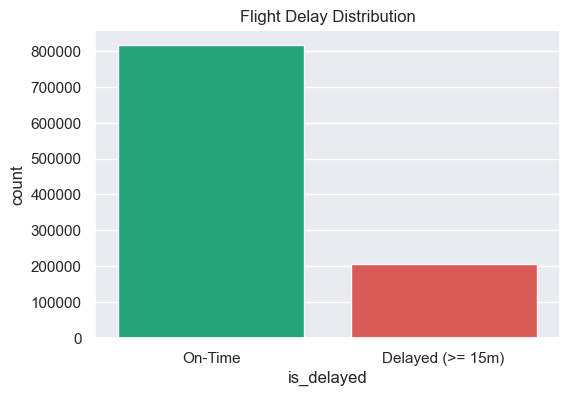

In [5]:
# Remove cancelled or diverted flights
clean_df = df[(df['cancelled'] == 0) & (df['diverted'] == 0)].copy()
clean_df = clean_df.dropna(subset=['arr_delay'])
print(f"Rows after cleaning: {len(clean_df):,}")

# Target Variable
clean_df['is_delayed'] = (clean_df['arr_delay'] >= 15).astype(int)

# Distribution
delayed_pct = clean_df['is_delayed'].mean() * 100
print(f"Dataset Distribution: {100-delayed_pct:.1f}% On-Time | {delayed_pct:.1f}% Delayed")

# Extract Departure and Arrival Hours from scheduled time
clean_df['dep_hour'] = clean_df['crs_dep_time'] // 100
clean_df['arr_hour'] = clean_df['crs_arr_time'] // 100

clean_df['dep_hour'] = clean_df['dep_hour'].clip(0, 23)
clean_df['arr_hour'] = clean_df['arr_hour'].clip(0, 23)

plt.figure(figsize=(6,4))
sns.countplot(x='is_delayed', data=clean_df, palette=['#10b981', '#ef4444'])
plt.title('Flight Delay Distribution')
plt.xticks([0, 1], ['On-Time', 'Delayed (>= 15m)'])
plt.show()


## 3. Feature Selection & Encoding
We intentionally exclude actual `dep_time`, `taxi_out`, and `arr_delay` features because these are known *during or after* the flight has occurred. We only use pre-flight scheduled parameters to train our predictive model.


In [6]:
feature_cols = [
    'month', 'day_of_month', 'day_of_week',
    'op_unique_carrier', 'origin', 'dest',
    'dep_hour', 'arr_hour',
    'crs_elapsed_time', 'distance'
]

X = clean_df[feature_cols].copy()
y = clean_df['is_delayed'].copy()
X = X.fillna(0)

# Label Encoders for categorical features
label_encoders = {}
categorical_cols = ['op_unique_carrier', 'origin', 'dest']

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded '{col}' to {len(le.classes_)} unique identities.")

# Split Data (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTrain shape: {X_train.shape} | Test shape: {X_test.shape}")


Encoded 'op_unique_carrier' to 15 unique identities.
Encoded 'origin' to 335 unique identities.
Encoded 'dest' to 334 unique identities.

Train shape: (818259, 10) | Test shape: (204565, 10)


## 4. Model Training & Comparison
We train 4 robust algorithms to find the best mapping of features.


In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42, n_jobs=-1),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    "LightGBM": LGBMClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1, verbose=-1),
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1, verbosity=0)
}

results = []

for name, model in models.items():
    print(f"Training {name}...")
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else 0
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "F1-Score": f1,
        "AUC-ROC": auc,
        "Train Time (s)": train_time,
        "_object": model,
        "_y_pred": y_pred
    })

res_df = pd.DataFrame(results).drop(columns=['_object', '_y_pred'])
display(res_df.sort_values('Accuracy', ascending=False))


Training Logistic Regression...
Training Random Forest...


MemoryError: Unable to allocate 6.24 MiB for an array with shape (818259,) and data type float64

## 5. Select Best Model & Visualize Integrity


In [ ]:
best_row = max(results, key=lambda x: x['Accuracy'])
best_name = best_row['Model']
best_model = best_row['_object']
best_y_pred = best_row['_y_pred']

print(f"🏆 BEST MODEL: {best_name} ({best_row['Accuracy']*100:.2f}% Accuracy)")

print("\nClassification Report:")
print(classification_report(y_test, best_y_pred, target_names=['On-Time', 'Delayed']))

cm = confusion_matrix(y_test, best_y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['On-Time', 'Delayed'], yticklabels=['On-Time', 'Delayed'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title(f'Confusion Matrix ({best_name})')
plt.show()


## 6. Feature Importance Investigation
Which features actually matter when predicting a delay?


In [ ]:
if hasattr(best_model, 'feature_importances_'):
    importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=True)

    plt.figure(figsize=(8,6))
    plt.barh(importance['Feature'], importance['Importance'], color='#8b5cf6')
    plt.title(f'Feature Importance ({best_name})')
    plt.xlabel('Influence Factor')
    plt.show()
else:
    print("Feature importance not supported for this model type/algorithm.")


## 7. Model Finalization
The model is saved into `flight_delay_model.pkl` allowing it to be natively invoked within our production Web Application environment.


In [ ]:
import joblib

joblib.dump(best_model, 'demo_best_model.pkl')
joblib.dump(label_encoders, 'demo_label_encoders.pkl')

print(f"Successfully packaged {best_name} into .pkl formats for production deployment. ✅")
